# Spatial Heatmap Visualization

Geospatial heatmaps with cartopy background and mask support.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Generate spatial test data
def gen_spatial_data(shape=(24, 24), pattern='temperature'):
    n_lat, n_lon = shape
    lat = np.linspace(0, 1, n_lat)
    lon = np.linspace(0, 1, n_lon)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    
    if pattern == 'temperature':
        base = 25 - 10 * lat_grid - 5 * lon_grid
        random = np.random.randn(n_lat, n_lon) * 2
        hotspots = np.zeros(shape)
        hotspots[5:8, 10:13] = 8
        hotspots[15:18, 5:8] = 6
        return base + random + hotspots
    
    elif pattern == 'chlorophyll':
        dist = np.abs(lat_grid - lon_grid)
        base = 10 * np.exp(-5 * dist)
        river = 15 * np.exp(-20 * (lon_grid - 0.3)**2 - 20 * (lat_grid - 0.7)**2)
        return base + river + np.random.randn(n_lat, n_lon) * 0.5
    
    else:
        return np.random.randn(n_lat, n_lon) * 10 + 50

# Generate data
temp_data = gen_spatial_data(pattern='temperature')
chl_data = gen_spatial_data(pattern='chlorophyll')

## Basic Heatmap


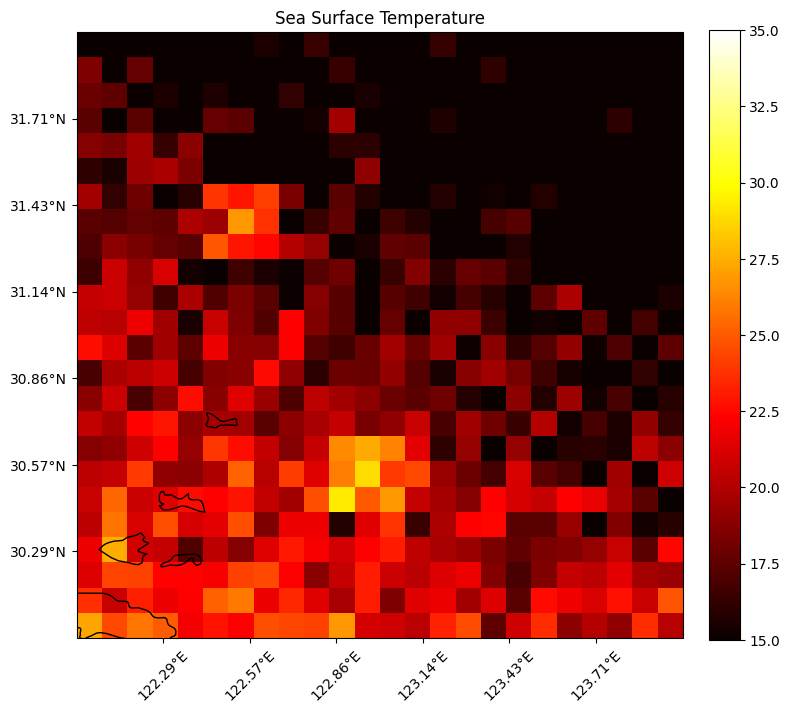

In [2]:
def plot_heatmap(data, title="", lon_range=(122, 124), lat_range=(30, 32), 
                vmin=None, vmax=None, cmap='jet'):
    """Plot geospatial heatmap"""
    lon_min, lon_max = lon_range
    lat_min, lat_max = lat_range
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    im = ax.imshow(data, extent=[lon_min, lon_max, lat_min, lat_max], 
                   origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    
    ax.coastlines(resolution='10m', linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    
    # Ticks
    lon_ticks = np.linspace(lon_min, lon_max, 8)[1:-1]
    lat_ticks = np.linspace(lat_min, lat_max, 8)[1:-1]
    ax.set_xticks(lon_ticks)
    ax.set_yticks(lat_ticks)
    ax.set_xticklabels([f"{x:.2f}°E" for x in lon_ticks], rotation=45)
    ax.set_yticklabels([f"{y:.2f}°N" for y in lat_ticks])
    
    if title:
        ax.set_title(title)
    
    plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig

fig = plot_heatmap(temp_data, "Sea Surface Temperature", vmin=15, vmax=35, cmap='hot')
plt.show()

## Multi-panel Comparison


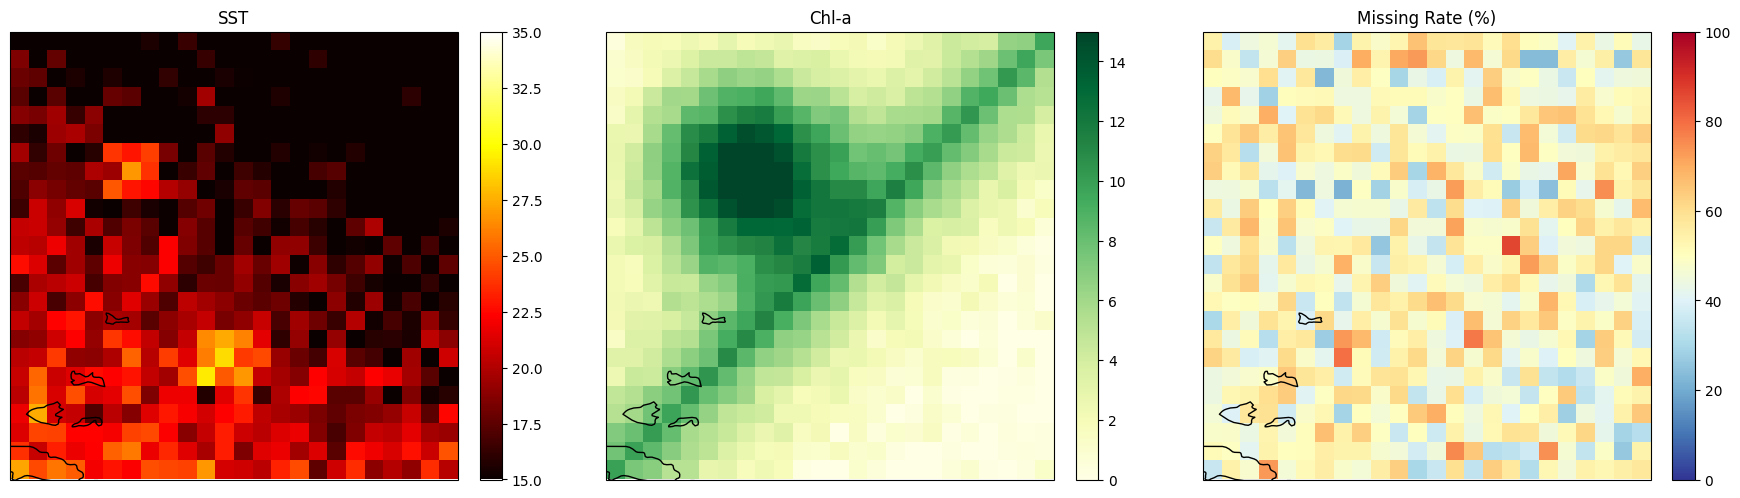

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), 
                        subplot_kw={'projection': ccrs.PlateCarree()})

# Temperature
ax1 = axes[0]
im1 = ax1.imshow(temp_data, extent=[122, 124, 30, 32], origin='lower', 
                cmap='hot', vmin=15, vmax=35)
ax1.coastlines(resolution='10m', linewidth=1)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax1.set_title('SST')
plt.colorbar(im1, ax=ax1, orientation='vertical', fraction=0.046, pad=0.04)

# Chlorophyll
ax2 = axes[1]
im2 = ax2.imshow(chl_data, extent=[122, 124, 30, 32], origin='lower', 
                cmap='YlGn', vmin=0, vmax=15)
ax2.coastlines(resolution='10m', linewidth=1)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax2.set_title('Chl-a')
plt.colorbar(im2, ax=ax2, orientation='vertical', fraction=0.046, pad=0.04)

# Missing rate
missing_data = gen_spatial_data(pattern='random')
missing_data = np.clip(missing_data, 0, 100)
ax3 = axes[2]
im3 = ax3.imshow(missing_data, extent=[122, 124, 30, 32], origin='lower', 
                cmap='RdYlBu_r', vmin=0, vmax=100)
ax3.coastlines(resolution='10m', linewidth=1)
ax3.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax3.set_title('Missing Rate (%)')
plt.colorbar(im3, ax=ax3, orientation='vertical', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Heatmap with Mask


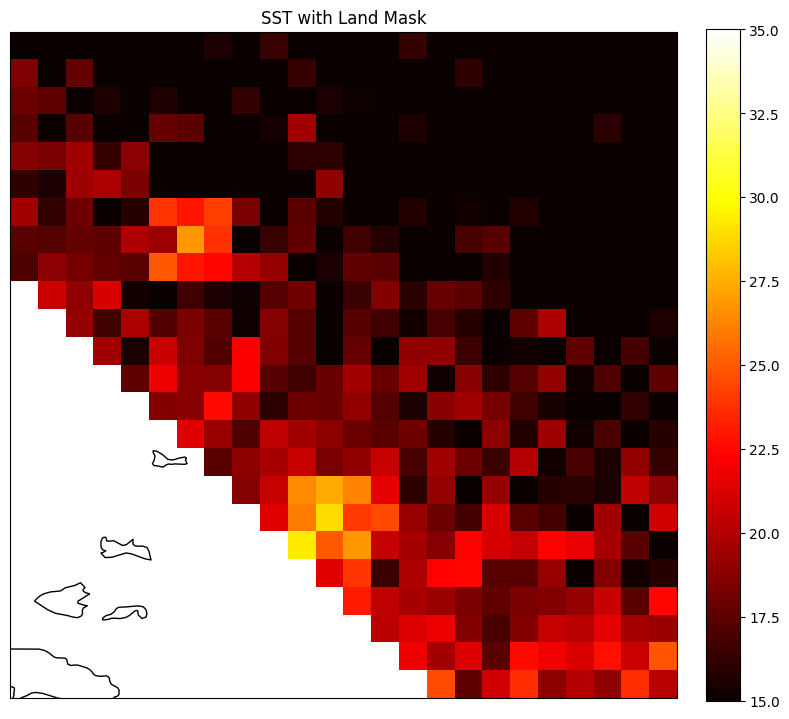

In [4]:
# Create land mask
def create_land_mask(shape=(24, 24)):
    mask = np.ones(shape)
    n_lat, n_lon = shape
    for i in range(n_lat):
        for j in range(n_lon):
            if i + j < n_lat * 0.6:  # Diagonal coastline
                mask[i, j] = 0
    return mask

land_mask = create_land_mask()

# Plot with mask
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Apply mask
masked_data = np.ma.masked_where(land_mask == 0, temp_data)

im = ax.imshow(masked_data, extent=[122, 124, 30, 32], 
               origin='lower', cmap='hot', vmin=15, vmax=35)

ax.coastlines(resolution='10m', linewidth=1)
ax.set_extent([122, 124, 30, 32])
ax.set_title('SST with Land Mask')

plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()